## **Лабораторная работа №1**

<font size= "4"> Задача регрессии</font>



In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from ml_library.metrics_regression import regression_metrics

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [35]:
data = fetch_california_housing(as_frame= True)

In [36]:
df = data.data

In [37]:
target = data.target

In [38]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [39]:
df_merge = pd.concat([df, target], axis = 1)

In [40]:
df_merge

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


#### Анализ данных

**Проверка на дубликаты**

In [41]:
df_merge.duplicated().sum()

np.int64(0)

**Пропущенные значения**

In [42]:
df_merge.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [43]:
df_merge.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


#### Анализ выбросов

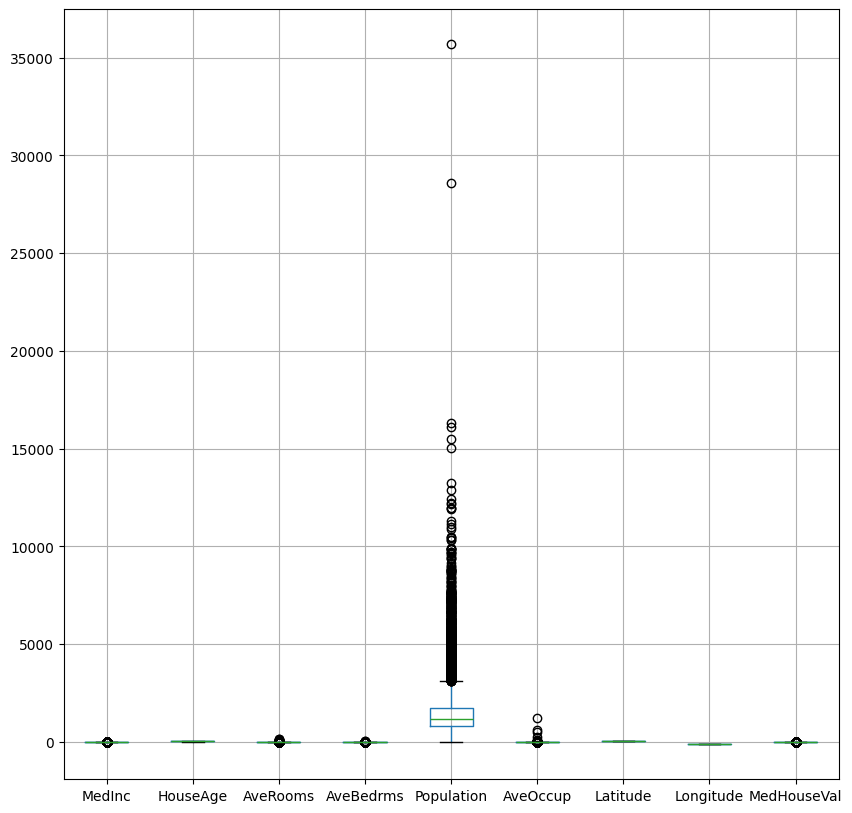

In [44]:
plt.figure(figsize=[10,10]);
df_merge.boxplot();

Наблюдаются выбросы у нескольких признаков:
- ```Ave Rooms```
- ``` MedInc ```
- ``` Ave Bedrms ```
- ``` Population ```
- ``` AveOccup ```
- ``` MedHouseVal```

#### Устранение выбросов

In [45]:
def iqr(df : pd.DataFrame, column: str) -> pd.DataFrame:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    return df[(df[column] >= lower) & (df[column]<= upper)]

In [46]:
for col in ['AveRooms', 'MedInc', 'AveBedrms', 'Population', 'AveOccup', 'MedHouseVal']:
    df_merge = iqr(df_merge, col)

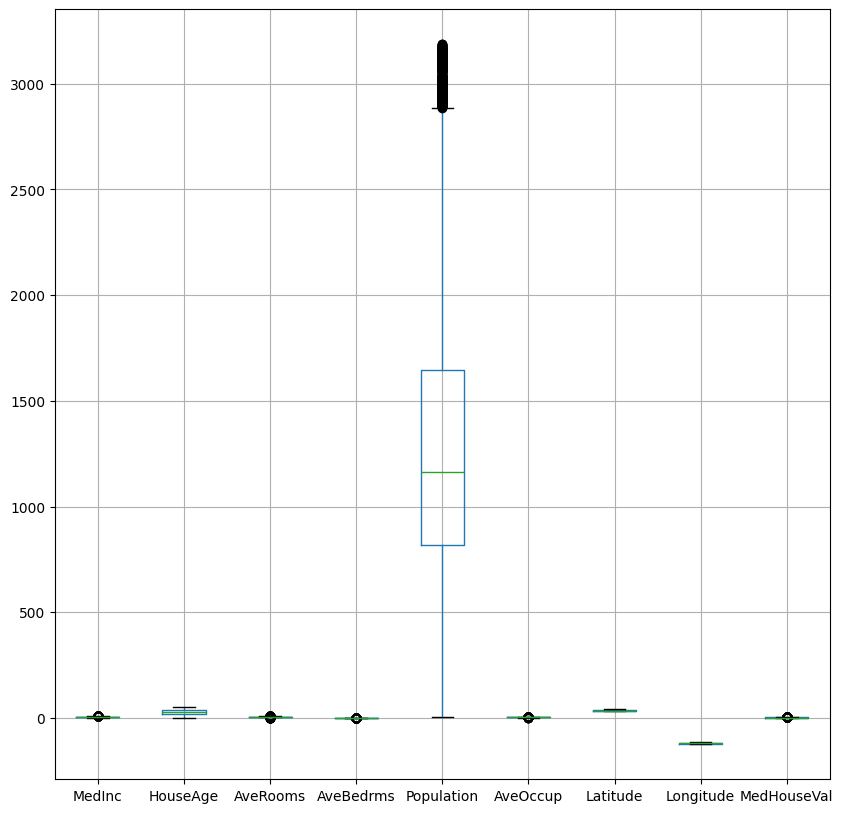

In [47]:
plt.figure(figsize=[10,10]);
df_merge.boxplot();

In [48]:
df_merge.shape

(16241, 9)

#### Гистограмма целевого признака

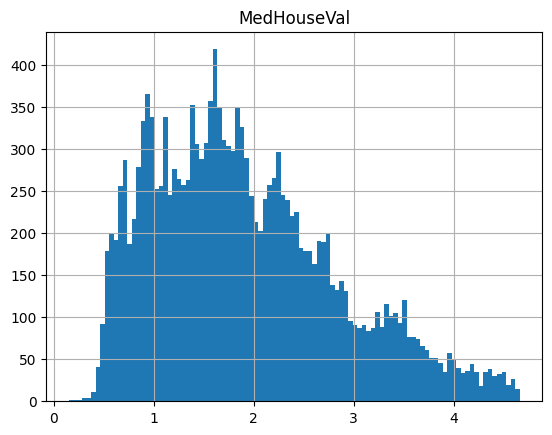

In [49]:
df_merge.hist(column='MedHouseVal', bins = 100);

Гистограмма с **правосторонней ассиметрией** (количество жилья с низкой стоимостью гораздо больше, чем с дорогой)

##### Тепловая карта

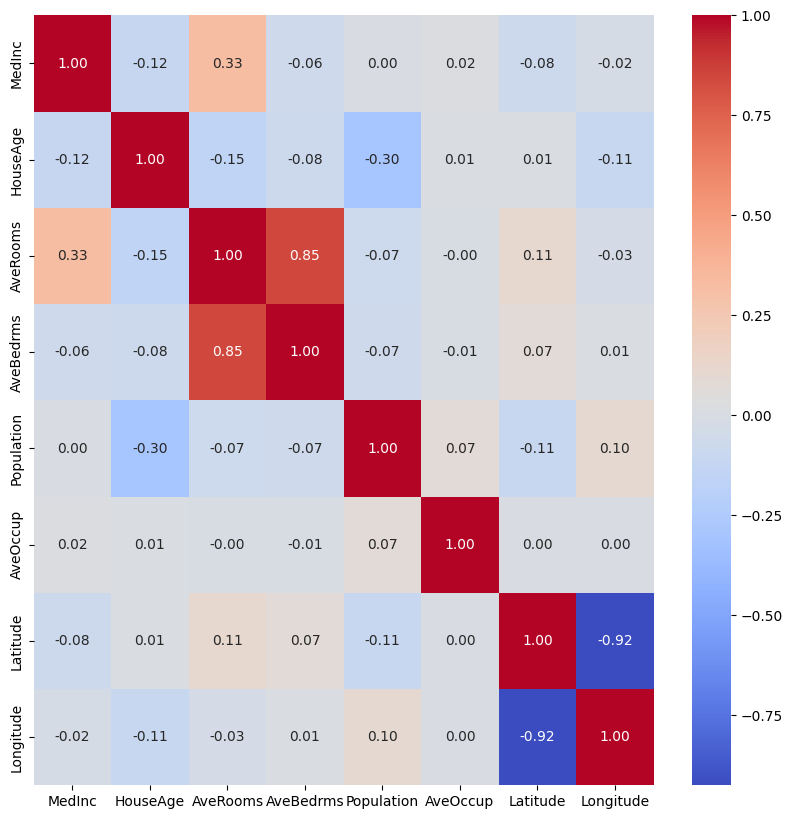

In [50]:
plt.figure(figsize=[10,10])
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f");

##### Особенности в данных:
- Слабая связь с целевой переменной
- Есть мультиколлинеарность 
- Есть нелинейные зависимости

Для решения задачи регрессии отлично подойдут деревья, а именно **градиетный бустинг**

#### **Предварительное обучение модели**


**Разделение данных на обучающую и тестовую выборки**
- Датасет состоит из небольшого количества наблюдений (15340 строк)
- Отношение 80/20 даст стабильную оценку качества, а также достаточное количество данных для обучения


**Основные метрики модели**
- MAE - интерпретируемая ошибка в долларах 
- R2 - доля объяснённой дисперсии 
- RMSE - чувствительна к большим ошибкам
- Within_percentage - бизнес-метрика (процент предсказаний в пределах X% от реальной цены) 

In [51]:
train_x, test_x,train_y, test_y = train_test_split(df_merge.drop(columns=['MedHouseVal']), df_merge['MedHouseVal'], test_size=0.2)

In [52]:
from sklearn.ensemble import GradientBoostingRegressor
first_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
first_model.fit(X=train_x, y=train_y)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [53]:
regression_metrics(test_y, first_model.predict(test_x), 10)

      Метрики качества
MAE            0.33120
RMSE           0.46146
R2             0.74643
WP            37.21145


**Отбор наиболее важных признаков**

In [54]:
first_model.feature_importances_

array([0.50649393, 0.0252054 , 0.03077704, 0.00305066, 0.00391991,
       0.12525016, 0.13391237, 0.17139053])

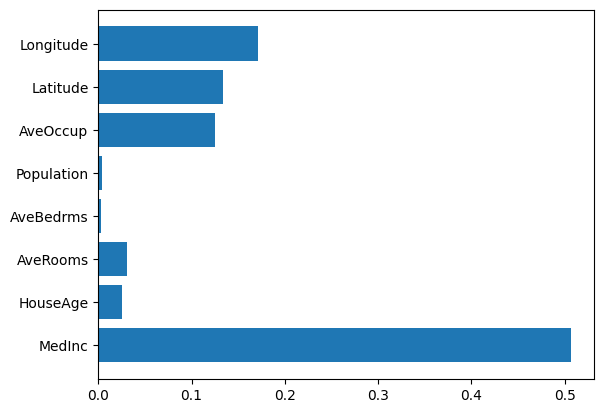

In [55]:
plt.barh(width=first_model.feature_importances_, y=df_merge.drop(columns=['MedHouseVal']).columns);

Удалим из рассмотрения признаки:
- ```Population```
- ```AveBedrms```

In [56]:
df_merge = df_merge.drop(columns=['Population', 'AveBedrms'])

In [57]:
X_train, X_test, Y_train, Y_test = train_test_split(df_merge.drop(columns=['MedHouseVal']),df_merge['MedHouseVal'],  test_size=0.2)

In [58]:
second_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
second_model.fit(X_train, Y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [59]:
regression_metrics(Y_test, second_model.predict(X_test), 10)

      Метрики качества
MAE            0.32877
RMSE           0.45969
R2             0.74958
WP            37.11911


Как видно: размерность уменьшилась, но метрики не поменялись

### Подбор гиперпараметров

In [ ]:
import optuna
from ml_library.hyperparams import gen_objective

gb_sklearn_grid = {
    'n_estimators': [50, 100, 200, 300, 500],  
    'learning_rate': (0.001, 0.3, True),  
    'max_depth': [3, 5, 10],  
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 5, 10],  
    'subsample': (0.5, 1.0),  
    'max_features': ['sqrt', 'log2', None, 0.5, 0.8],  
    'min_weight_fraction_leaf': (0.0, 0.5),
    'min_impurity_decrease': (0.0, 0.1),
}

In [ ]:
gb_objective = gen_objective(GradientBoostingRegressor, gb_sklearn_grid, X_train, Y_train)

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(gb_objective, n_trials=100)
best_params = study.best_params

In [84]:
best_params

{'n_estimators': 500,
 'learning_rate': 0.08909614138396175,
 'max_depth': 5,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'subsample': 0.8850778401729722,
 'max_features': None,
 'min_weight_fraction_leaf': 0.0009891642406056394,
 'min_impurity_decrease': 0.007474480196941247}

In [83]:
best_gb_model = GradientBoostingRegressor(**best_params).fit(X_train, Y_train)

### Предсказания полученной модели

In [86]:
regression_metrics(Y_test, best_gb_model.predict(X_test), 10)

      Метрики качества
MAE            0.26428
RMSE           0.39132
R2             0.81854
WP            47.36842


### Построение графиков остатков 

In [103]:
from ml_library.graphics import plot_regression_actual, plot_regression_residuals

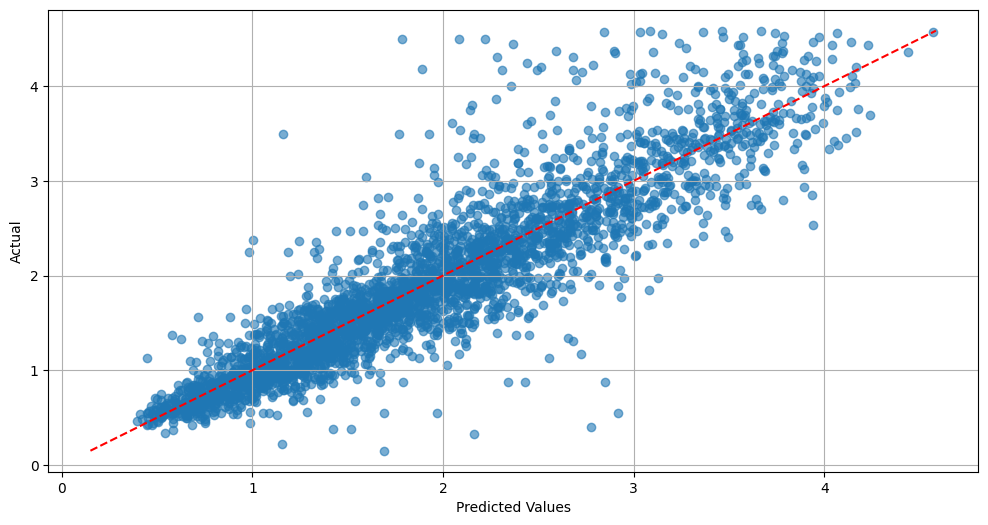

In [104]:
plot_regression_actual(best_gb_model, X_test, Y_test);

#### Анализ графика

- Точки рассеяны вокруг идеальной линии предсказаний
- Равномерное распределени точек выше и ниже линии
- Большинство точек близки к диагональной линии, что говорит о хорошей точности модели

Можно сделать вывод, что модель:
- адекватно оценивает стоимость жилья
- работает хорошо для домов разного ценового сегмента

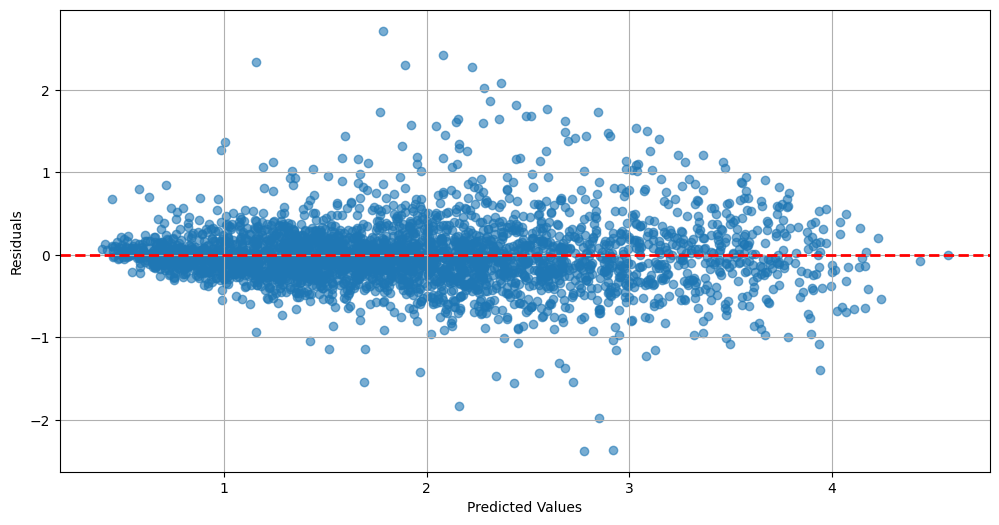

In [105]:
plot_regression_residuals(best_gb_model, X_test, Y_test)

#### Анализ графика

- Большой разброс, что говорит о ошибках предсказаний
- Наблюдается случайный разброс, что говорит об остутсвии закономерностей в предсказании
- Разброс примерно одинаковый по всем ценовым диапазоном